# Dual-Dataset Understanding and Preparation

**Research context:** Early-stage risk of problematic reward-seeking digital behaviours in young adults  
**Module:** IT41012 Research Methodology  
**Scope of this notebook:** Data loading → inspection → EDA → cleaning → feature analysis/selection/engineering → validation → final prepared datasets. **No modelling.**

## Locked decisions

| Decision | Choice |
|----------|--------|
| Dataset treatment | Both datasets prepared equally (no join) |
| Dataset 1 target | 3-class `risk_level`: NaN/Mild → Low; Moderate → Moderate; Severe → High |
| Dataset 2 target | 3-class `risk_level` from `Self_Reported_Addiction_Level`: High+Severe → High |
| Population (D2) | Filter to ages 18–35 to align with young-adult scope |
| Modelling | Deferred; SMOTE and scaling deferred to a later modelling notebook |

## Notebook sections

1. Data Loading  
2. Dataset Inspection  
3. Exploratory Data Analysis (EDA)  
4. Data Cleaning  
5. Feature Analysis  
6. Feature Selection  
7. Feature Engineering  
8. Data Validation  
9. Final Dataset Preparation

## Setup

Load libraries, fix a random seed for reproducibility, and define shared helper functions used by both dataset tracks.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Resolve project root whether the kernel CWD is repo root or notebooks/
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / "Data").exists() else CWD.parent
DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 12

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_DIR     = {DATA_DIR}")

PROJECT_ROOT = C:\Users\ishan\OneDrive\Documents\Work\3 Year 2 Semester\IT41012 - Research Methodology\Research Paper\reward-seeking-behavior-ml
DATA_DIR     = C:\Users\ishan\OneDrive\Documents\Work\3 Year 2 Semester\IT41012 - Research Methodology\Research Paper\reward-seeking-behavior-ml\Data


In [2]:
def missingness_table(df: pd.DataFrame) -> pd.DataFrame:
    """Return missing-value counts and percentages."""
    missing = df.isna().sum()
    out = pd.DataFrame(
        {
            "n_missing": missing,
            "pct_missing": (100 * missing / len(df)).round(2),
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique(dropna=False),
        }
    )
    return out.sort_values("n_missing", ascending=False)


def iqr_outlier_report(df: pd.DataFrame, cols: list[str] | None = None) -> pd.DataFrame:
    """Flag values outside Tukey IQR fences (1.5 * IQR)."""
    cols = cols or df.select_dtypes(include=[np.number]).columns.tolist()
    rows = []
    for col in cols:
        series = df[col].dropna()
        if series.empty:
            continue
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((series < low) | (series > high)).sum())
        rows.append(
            {
                "feature": col,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "fence_low": low,
                "fence_high": high,
                "n_outliers": n_out,
                "pct_outliers": round(100 * n_out / len(series), 2),
            }
        )
    return pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)


def negative_value_audit(df: pd.DataFrame, cols: list[str] | None = None) -> pd.DataFrame:
    """Count negative values in numeric columns (domain-invalid for hours/usage)."""
    cols = cols or df.select_dtypes(include=[np.number]).columns.tolist()
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        n_neg = int((df[col] < 0).sum())
        if n_neg > 0:
            rows.append(
                {
                    "feature": col,
                    "n_negative": n_neg,
                    "pct_negative": round(100 * n_neg / len(df), 2),
                    "min": df[col].min(),
                }
            )
    if not rows:
        return pd.DataFrame(columns=["feature", "n_negative", "pct_negative", "min"])
    return pd.DataFrame(rows).sort_values("n_negative", ascending=False)


def plot_numeric_distributions(df: pd.DataFrame, cols: list[str], title_prefix: str, ncols: int = 3):
    """Histogram grid for numeric features."""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
        axes[i].set_title(col, fontsize=10)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"{title_prefix}: numeric distributions", y=1.01)
    fig.tight_layout()
    plt.show()


def plot_categorical_bars(df: pd.DataFrame, cols: list[str], title_prefix: str):
    """Bar charts for categorical features."""
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        vc = df[col].fillna("MISSING").value_counts()
        ax.bar(vc.index.astype(str), vc.values, color="teal")
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=30)
    fig.suptitle(f"{title_prefix}: categorical counts", y=1.02)
    fig.tight_layout()
    plt.show()


def correlation_heatmap(df: pd.DataFrame, cols: list[str], title: str):
    """Pearson correlation heatmap for numeric columns."""
    corr = df[cols].corr(numeric_only=True)
    plt.figure(figsize=(max(8, 0.55 * len(cols)), max(6, 0.45 * len(cols))))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return corr


print("Helpers ready.")

Helpers ready.


---
# 1. Data Loading

**What:** Load both CSVs from `Data/`.  
**Why:** Establish reproducible inputs and baseline shapes before any transformation.  
**Assumption:** Files are UTF-8 CSVs with a header row (verified on load).

In [3]:
PATH_D1 = DATA_DIR / "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"
PATH_D2 = DATA_DIR / "mobile_addiction_data.csv"

df1_raw = pd.read_csv(PATH_D1)
df2_raw = pd.read_csv(PATH_D2)

summary_load = pd.DataFrame(
    [
        {
            "dataset": "Dataset 1 — Smartphone Usage & Addiction",
            "path": PATH_D1.name,
            "n_rows": df1_raw.shape[0],
            "n_cols": df1_raw.shape[1],
            "memory_mb": round(df1_raw.memory_usage(deep=True).sum() / 1e6, 2),
        },
        {
            "dataset": "Dataset 2 — Mobile Addiction Data",
            "path": PATH_D2.name,
            "n_rows": df2_raw.shape[0],
            "n_cols": df2_raw.shape[1],
            "memory_mb": round(df2_raw.memory_usage(deep=True).sum() / 1e6, 2),
        },
    ]
)
summary_load

,dataset,path,n_rows,n_cols,memory_mb
0,Dataset 1 — Smartphone Usage & Addiction,Smartphone_Usage_And_Addiction_Analysis_7500_R...,7500,16,1.20
1,Dataset 2 — Mobile Addiction Data,mobile_addiction_data.csv,3000,34,0.99


In [4]:
print("Dataset 1 columns:")
print(list(df1_raw.columns))
print("\nDataset 2 columns:")
print(list(df2_raw.columns))

Dataset 1 columns:
['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']

Dataset 2 columns:
['User_ID', 'Country', 'Age', 'Gender', 'Occupation', 'Education_Level', 'Income_USD', 'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Mental_Health_Score', 'Depression_Score', 'Anxiety_Score', 'Stress_Level', 'Relationship_Status', 'Has_Children', 'Urban_or_Rural', 'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours', 'Internet_Connection_Type', 'Primary_Device_Brand', 'Has_Screen_Time_Management_App', 'Self_Reported_Addiction_Level', 'Monthly_Data_Usage_GB', 'Has_Night_Mode_On', 'Age

---
# 2. Dataset Inspection

**What:** Document the purpose of each column and identify likely targets, IDs, and leakage risks.  
**Why:** Feature decisions must follow domain roles and prediction-time availability, not convenience.  
**Conclusion preview:** The two datasets are **not joinable** (different IDs, schemas, populations, and label definitions). They will be prepared as **parallel tracks**.

## 2A. Dataset 1 — column roles

| Column | Role | Notes |
|--------|------|-------|
| `transaction_id`, `user_id` | Identifier | Drop for modelling |
| `age`, `gender` | Demographic features | Age already in young-adult range (18–35) |
| `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`, `work_study_hours`, `weekend_screen_time` | Usage volume | Aligns with proposal usage features |
| `notifications_per_day`, `app_opens_per_day` | Interaction frequency | Proxy for pickups / app switching |
| `sleep_hours`, `stress_level` | Lifestyle | Proposal-listed |
| `academic_work_impact` | Likely **outcome / consequence** | Not available as a clean early predictor; leakage risk |
| `addiction_level` | Ordinal severity label | Source for 3-class `risk_level` (NaNs present) |
| `addicted_label` | Binary label | Deterministic function of `addiction_level`; validation only |

**Likely prediction target:** 3-class `risk_level` derived from `addiction_level`.

In [5]:
print("Dataset 1 dtypes:")
display(df1_raw.dtypes.to_frame("dtype"))
print("Missingness:")
display(missingness_table(df1_raw))
print(f"Duplicate rows: {df1_raw.duplicated().sum()}")
print(f"Duplicate user_id: {df1_raw['user_id'].duplicated().sum()}")

Dataset 1 dtypes:


,dtype
transaction_id,str
user_id,str
age,int64
gender,str
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,int64


Missingness:


,n_missing,pct_missing,dtype,n_unique
addiction_level,819,10.92,str,4
transaction_id,0,0.00,str,7500
user_id,0,0.00,str,7500
age,0,0.00,int64,18
gender,0,0.00,str,3
daily_screen_time_hours,0,0.00,float64,900
social_media_hours,0,0.00,float64,551
gaming_hours,0,0.00,float64,401
work_study_hours,0,0.00,float64,551
sleep_hours,0,0.00,float64,451


Duplicate rows: 0
Duplicate user_id: 0


In [6]:
# Evidence: addiction_level vs addicted_label consistency
ct = pd.crosstab(
    df1_raw["addiction_level"].fillna("MISSING"),
    df1_raw["addicted_label"],
    dropna=False,
)
print("Crosstab addiction_level × addicted_label:")
display(ct)

# Decision evidence: Mild/MISSING always map to 0; Moderate/Severe always map to 1
low_rows = ct.loc[[i for i in ["MISSING", "Mild"] if i in ct.index]]
high_rows = ct.loc[[i for i in ["Moderate", "Severe"] if i in ct.index]]
assert (low_rows.get(1, pd.Series(dtype=int)).fillna(0) == 0).all()
assert (high_rows.get(0, pd.Series(dtype=int)).fillna(0) == 0).all()
print("Conclusion: addicted_label is a deterministic collapse of addiction_level severity.")
print("Using both as features would constitute target leakage.")

Crosstab addiction_level × addicted_label:


addicted_label,0,1
addiction_level,,
MISSING,819,0
Mild,1373,0
Moderate,0,2874
Severe,0,2434


Conclusion: addicted_label is a deterministic collapse of addiction_level severity.
Using both as features would constitute target leakage.


### Decision / Evidence / Assumption — Dataset 1 target

- **Decision:** Create `risk_level` ∈ {Low, Moderate, High} from `addiction_level` with NaN/Mild → Low, Moderate → Moderate, Severe → High.  
- **Evidence:** Crosstab shows Mild and missing severity are exclusively `addicted_label=0`; Moderate/Severe are exclusively `1`. Mapping preserves ordinal severity while matching the proposal’s three risk tiers.  
- **Assumption:** Missing `addiction_level` represents non/low problematic use rather than a recording error (supported by exclusive mapping to label 0). Uncertainty remains if missingness were MNAR for another reason; we state this explicitly.

## 2B. Dataset 2 — column roles

| Group | Columns | Notes |
|-------|---------|-------|
| ID | `User_ID` | Drop for modelling |
| Demographics / SES | `Country`, `Age`, `Gender`, `Occupation`, `Education_Level`, `Income_USD`, `Relationship_Status`, `Has_Children`, `Urban_or_Rural` | Age spans 12–70; filter to 18–35 |
| Usage / interaction | Screen, unlocks, social, gaming, streaming, messaging, work, shopping, notifications, data GB | Core behavioural signals |
| Lifestyle | `Sleep_Hours`, `Physical_Activity_Hours`, `Time_Spent_With_Family_Hours`, `Stress_Level` | Proposal-aligned |
| Device / settings | Connection, brand, night mode, screen-time app, tech savviness, age first phone | Mixed relevance; brand likely low information |
| Clinical scores | `Mental_Health_Score`, `Depression_Score`, `Anxiety_Score` | Concurrent outcomes → **exclude** from predictors (leakage / circularity) |
| Label | `Self_Reported_Addiction_Level` | Source for 3-class `risk_level` |

**Likely prediction target:** 3-class remapping of `Self_Reported_Addiction_Level` (High + Severe → High).

In [7]:
print("Dataset 2 dtypes:")
display(df2_raw.dtypes.to_frame("dtype"))
print("Missingness:")
display(missingness_table(df2_raw))
print(f"Duplicate rows: {df2_raw.duplicated().sum()}")
print(f"Duplicate User_ID: {df2_raw['User_ID'].duplicated().sum()}")
print("Age range:", df2_raw["Age"].min(), "–", df2_raw["Age"].max())
print("Self_Reported_Addiction_Level counts:")
display(df2_raw["Self_Reported_Addiction_Level"].value_counts())
display(negative_value_audit(df2_raw))

Dataset 2 dtypes:


,dtype
User_ID,int64
Country,str
Age,int64
Gender,str
Occupation,str
Education_Level,str
Income_USD,float64
Daily_Screen_Time_Hours,float64
Phone_Unlocks_Per_Day,int64
Social_Media_Usage_Hours,float64


Missingness:


,n_missing,pct_missing,dtype,n_unique
Education_Level,612,20.4,str,5
User_ID,0,0.0,int64,3000
Primary_Device_Brand,0,0.0,str,6
Relationship_Status,0,0.0,str,4
Has_Children,0,0.0,str,2
Urban_or_Rural,0,0.0,str,2
Time_Spent_With_Family_Hours,0,0.0,float64,404
Online_Shopping_Hours,0,0.0,float64,274
Internet_Connection_Type,0,0.0,str,4
Has_Screen_Time_Management_App,0,0.0,str,2


Duplicate rows: 0
Duplicate User_ID: 0
Age range: 12 – 70
Self_Reported_Addiction_Level counts:


Self_Reported_Addiction_Level
High        764
Low         756
Severe      750
Moderate    730
Name: count, dtype: int64

,feature,n_negative,pct_negative,min
4,Gaming_Usage_Hours,213,7.10,-1.93
10,Online_Shopping_Hours,181,6.03,-0.88
9,Time_Spent_With_Family_Hours,96,3.20,-1.61
0,Income_USD,81,2.70,-25622.66
8,Physical_Activity_Hours,80,2.67,-0.84
3,Social_Media_Usage_Hours,70,2.33,-1.81
5,Streaming_Usage_Hours,67,2.23,-1.91
7,Work_Related_Usage_Hours,53,1.77,-1.16
11,Monthly_Data_Usage_GB,16,0.53,-10.96
1,Daily_Screen_Time_Hours,9,0.30,-0.50


## 2C. Cross-dataset relationship

| Question | Finding |
|----------|---------|
| Shared keys? | No common user identifiers (`user_id` vs `User_ID` with incompatible formats) |
| Same population? | D1 is 18–35 only; D2 is 12–70 |
| Same label? | D1 severity + binary vs D2 4-level self-report |
| Joinable? | **No** — prepare separately |

**Conclusion:** Treat as two independent evidence tracks for the same research questions, not a single pooled table.

---
# 3. Exploratory Data Analysis (EDA)

**What:** Quantify distributions, imbalance, outliers, correlations, and data-quality issues.  
**Why:** Feature keep/drop and cleaning rules must be evidence-based.

## 3A. Dataset 1 — EDA

Provisional risk_level distribution:


risk_level
Moderate    2874
High        2434
Low         2192
Name: count, dtype: int64

risk_level
Moderate    38.32
High        32.45
Low         29.23
Name: pct, dtype: float64

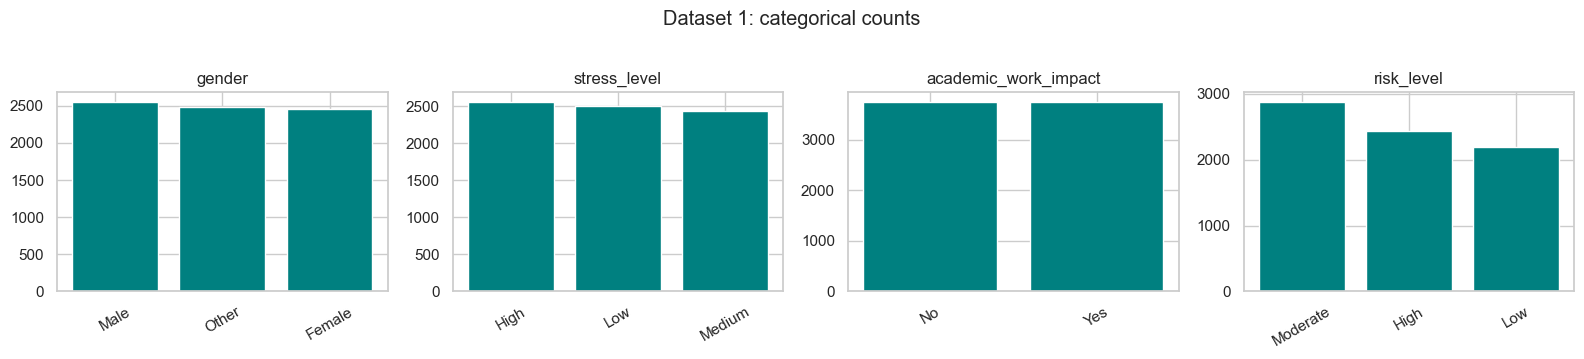

In [8]:
# Provisional 3-class target for EDA (finalised in cleaning)
risk_map_d1 = {"Mild": "Low", "Moderate": "Moderate", "Severe": "High"}
df1_eda = df1_raw.copy()
df1_eda["risk_level"] = df1_eda["addiction_level"].map(risk_map_d1)
df1_eda.loc[df1_eda["addiction_level"].isna(), "risk_level"] = "Low"

print("Provisional risk_level distribution:")
display(df1_eda["risk_level"].value_counts())
display((100 * df1_eda["risk_level"].value_counts(normalize=True)).round(2).rename("pct"))

plot_categorical_bars(
    df1_eda,
    ["gender", "stress_level", "academic_work_impact", "risk_level"],
    "Dataset 1",
)

,count,mean,std,min,25%,50%,75%,max
age,7500.0,26.568800,5.197108,18.00,22.00,27.000,31.00,35.00
daily_screen_time_hours,7500.0,7.499912,2.609188,3.00,5.22,7.525,9.81,12.00
social_media_hours,7500.0,3.273484,1.585342,0.50,1.91,3.270,4.63,6.00
gaming_hours,7500.0,2.014183,1.146039,0.00,1.02,2.040,2.99,4.00
work_study_hours,7500.0,3.242420,1.600765,0.50,1.85,3.230,4.64,6.00
sleep_hours,7500.0,6.737561,1.283605,4.50,5.63,6.720,7.84,9.00
notifications_per_day,7500.0,134.257333,66.586883,20.00,76.00,134.000,191.00,250.00
app_opens_per_day,7500.0,97.832400,48.423349,15.00,55.00,98.000,140.00,180.00
weekend_screen_time,7500.0,9.243827,2.718281,3.58,6.96,9.260,11.54,14.88


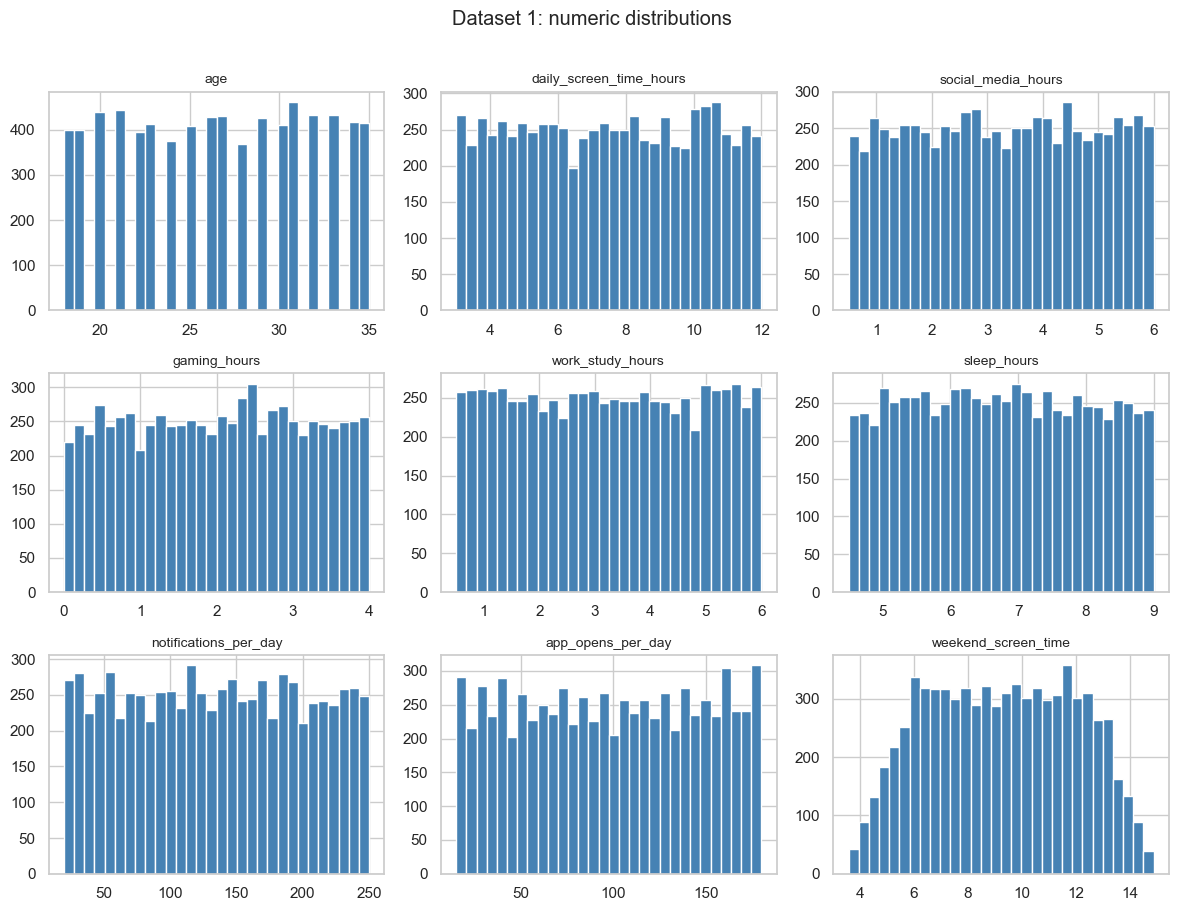

,feature,q1,q3,iqr,fence_low,fence_high,n_outliers,pct_outliers
0,age,22.00,31.00,9.00,8.500,44.500,0,0.0
1,daily_screen_time_hours,5.22,9.81,4.59,-1.665,16.695,0,0.0
2,social_media_hours,1.91,4.63,2.72,-2.170,8.710,0,0.0
3,gaming_hours,1.02,2.99,1.97,-1.935,5.945,0,0.0
4,work_study_hours,1.85,4.64,2.79,-2.335,8.825,0,0.0
5,sleep_hours,5.63,7.84,2.21,2.315,11.155,0,0.0
6,notifications_per_day,76.00,191.00,115.00,-96.500,363.500,0,0.0
7,app_opens_per_day,55.00,140.00,85.00,-72.500,267.500,0,0.0
8,weekend_screen_time,6.96,11.54,4.58,0.090,18.410,0,0.0


In [9]:
num_cols_d1 = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
]
display(df1_eda[num_cols_d1].describe().T)
plot_numeric_distributions(df1_eda, num_cols_d1, "Dataset 1")
display(iqr_outlier_report(df1_eda, num_cols_d1))

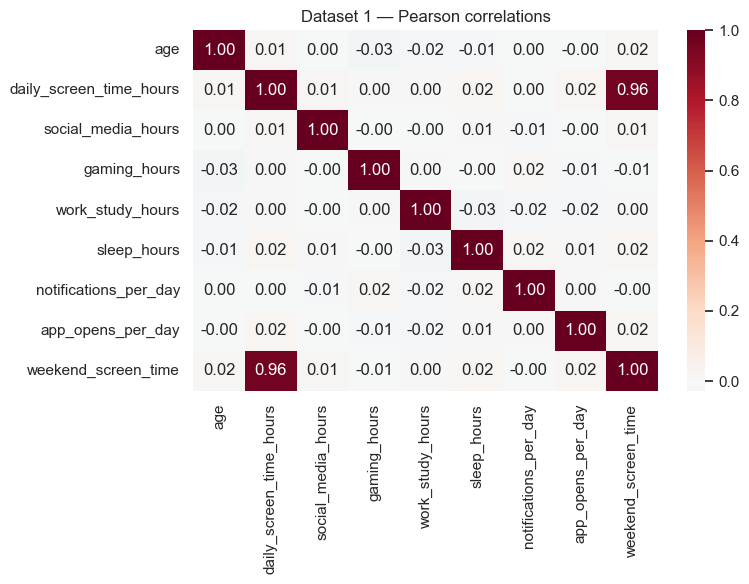

Highest absolute correlations (|r| >= 0.5):


,,abs_r
daily_screen_time_hours,weekend_screen_time,0.964295


In [10]:
corr1 = correlation_heatmap(df1_eda, num_cols_d1, "Dataset 1 — Pearson correlations")
print("Highest absolute correlations (|r| >= 0.5):")
pairs = (
    corr1.where(np.triu(np.ones(corr1.shape), k=1).astype(bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
display(pairs[pairs >= 0.5].to_frame("abs_r"))

In [11]:
# Association of numeric features with provisional ordinal risk
risk_ord = df1_eda["risk_level"].map({"Low": 0, "Moderate": 1, "High": 2})
assoc_rows = []
for col in num_cols_d1:
    r, p = stats.spearmanr(df1_eda[col], risk_ord, nan_policy="omit")
    assoc_rows.append({"feature": col, "spearman_r": r, "p_value": p})
assoc_d1 = pd.DataFrame(assoc_rows).sort_values("spearman_r", key=np.abs, ascending=False)
display(assoc_d1)

,feature,spearman_r,p_value
1,daily_screen_time_hours,0.504823,0.000000e+00
8,weekend_screen_time,0.493120,0.000000e+00
2,social_media_hours,0.384175,2.401951e-262
5,sleep_hours,0.033497,3.716332e-03
0,age,0.017763,1.239957e-01
7,app_opens_per_day,0.011516,3.186648e-01
6,notifications_per_day,-0.009288,4.212364e-01
4,work_study_hours,0.001944,8.663513e-01
3,gaming_hours,0.001836,8.736779e-01


### Dataset 1 — EDA conclusions

- **Class balance:** Three-class mapping yields a non-uniform distribution (Moderate typically largest; Low includes Mild + former NaNs). Imbalance handling (e.g. SMOTE) belongs in a **later modelling** notebook, not in the saved prepared CSV.
- **Data quality:** No duplicate rows; numeric missingness is zero; only `addiction_level` has missing values (reinterpreted as Low).
- **Outliers:** Tukey fences may flag extremes in notifications/app opens; retain unless physically impossible — behavioural tails can be informative for high-risk users.
- **Correlation / redundancy:** Inspect weekend vs daily screen correlation in the heatmap; keep both if they capture distinct weekday/weekend reward-seeking patterns and |r| is not near-perfect.
- **Leakage signal:** `academic_work_impact` is an impact outcome; exclude from predictors.

## 3B. Dataset 2 — EDA

In [12]:
df2_eda = df2_raw.copy()
print("Original 4-class Self_Reported_Addiction_Level:")
display(df2_eda["Self_Reported_Addiction_Level"].value_counts())

risk_map_d2 = {
    "Low": "Low",
    "Moderate": "Moderate",
    "High": "High",
    "Severe": "High",
}
df2_eda["risk_level"] = df2_eda["Self_Reported_Addiction_Level"].map(risk_map_d2)
print("Provisional 3-class risk_level (full age range):")
display(df2_eda["risk_level"].value_counts())

age_mask = (df2_eda["Age"] >= 18) & (df2_eda["Age"] <= 35)
print(f"Rows aged 18–35: {age_mask.sum()} / {len(df2_eda)} ({100*age_mask.mean():.1f}%)")
print("Risk distribution within ages 18–35:")
display(df2_eda.loc[age_mask, "risk_level"].value_counts())

Original 4-class Self_Reported_Addiction_Level:


Self_Reported_Addiction_Level
High        764
Low         756
Severe      750
Moderate    730
Name: count, dtype: int64

Provisional 3-class risk_level (full age range):


risk_level
High        1514
Low          756
Moderate     730
Name: count, dtype: int64

Rows aged 18–35: 904 / 3000 (30.1%)
Risk distribution within ages 18–35:


risk_level
High        468
Moderate    221
Low         215
Name: count, dtype: int64

In [13]:
num_cols_d2 = df2_eda.select_dtypes(include=[np.number]).columns.tolist()
num_cols_d2 = [c for c in num_cols_d2 if c != "User_ID"]
display(negative_value_audit(df2_eda, num_cols_d2))
display(iqr_outlier_report(df2_eda, num_cols_d2).head(15))

,feature,n_negative,pct_negative,min
4,Gaming_Usage_Hours,213,7.10,-1.93
10,Online_Shopping_Hours,181,6.03,-0.88
9,Time_Spent_With_Family_Hours,96,3.20,-1.61
0,Income_USD,81,2.70,-25622.66
8,Physical_Activity_Hours,80,2.67,-0.84
3,Social_Media_Usage_Hours,70,2.33,-1.81
5,Streaming_Usage_Hours,67,2.23,-1.91
7,Work_Related_Usage_Hours,53,1.77,-1.16
11,Monthly_Data_Usage_GB,16,0.53,-10.96
1,Daily_Screen_Time_Hours,9,0.30,-0.50


,feature,q1,q3,iqr,fence_low,fence_high,n_outliers,pct_outliers
3,Phone_Unlocks_Per_Day,63.0000,96.0000,33.0000,13.50000,145.50000,31,1.03
10,Physical_Activity_Hours,0.6500,1.3300,0.6800,-0.37000,2.35000,29,0.97
15,Time_Spent_With_Family_Hours,0.9200,1.9900,1.0700,-0.68500,3.59500,29,0.97
2,Daily_Screen_Time_Hours,4.5975,7.3025,2.7050,0.54000,11.36000,27,0.90
4,Social_Media_Usage_Hours,1.3400,2.6400,1.3000,-0.61000,4.59000,26,0.87
19,Push_Notifications_Per_Day,79.0000,119.0000,40.0000,19.00000,179.00000,24,0.80
8,Work_Related_Usage_Hours,1.3400,2.6700,1.3300,-0.65500,4.66500,23,0.77
6,Streaming_Usage_Hours,1.2900,2.6500,1.3600,-0.75000,4.69000,22,0.73
9,Sleep_Hours,5.8400,7.1600,1.3200,3.86000,9.14000,21,0.70
16,Online_Shopping_Hours,0.4600,1.1300,0.6700,-0.54500,2.13500,21,0.70


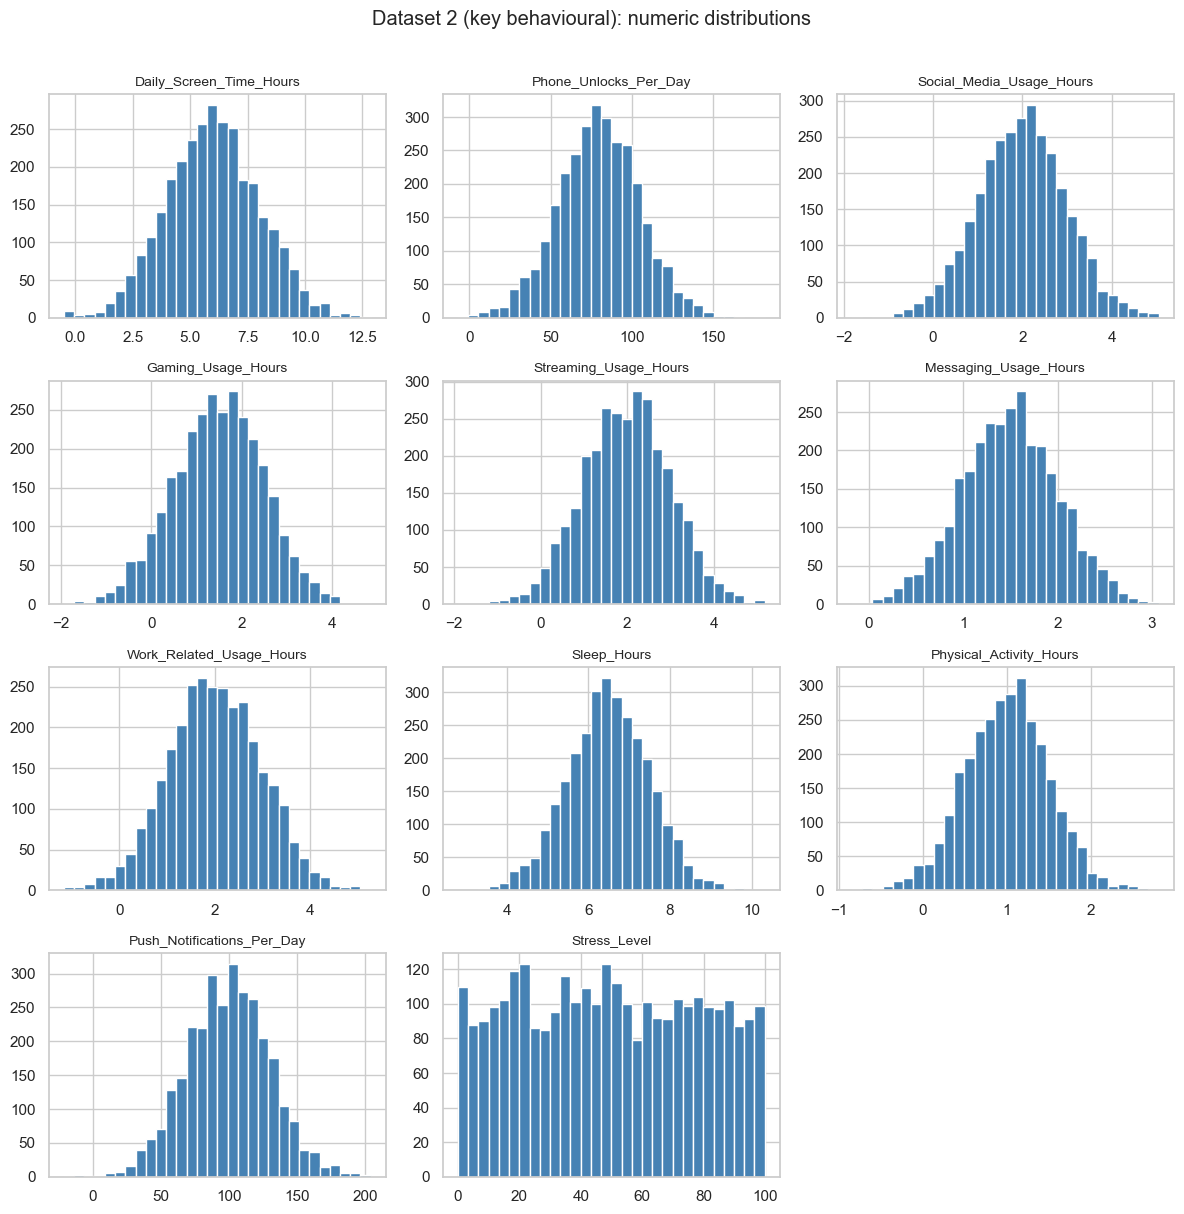

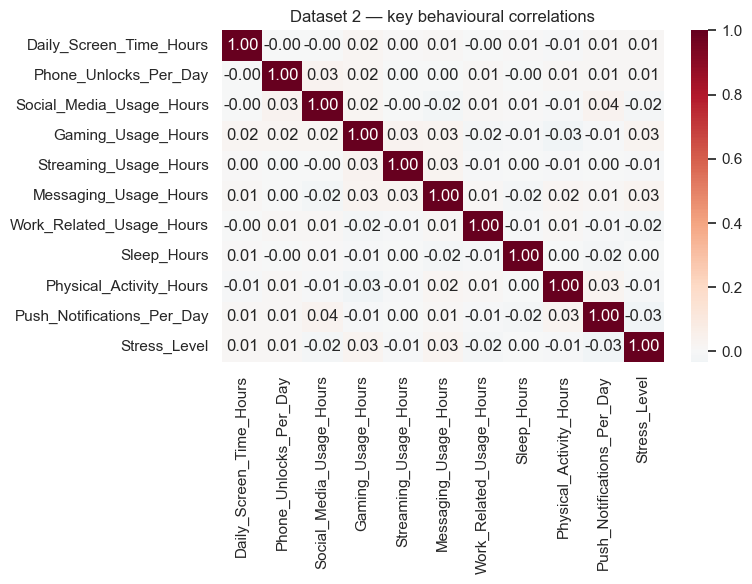

In [14]:
usage_cols_d2 = [
    "Daily_Screen_Time_Hours",
    "Phone_Unlocks_Per_Day",
    "Social_Media_Usage_Hours",
    "Gaming_Usage_Hours",
    "Streaming_Usage_Hours",
    "Messaging_Usage_Hours",
    "Work_Related_Usage_Hours",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Push_Notifications_Per_Day",
    "Stress_Level",
]
plot_numeric_distributions(df2_eda, usage_cols_d2, "Dataset 2 (key behavioural)")
corr2 = correlation_heatmap(df2_eda, usage_cols_d2, "Dataset 2 — key behavioural correlations")

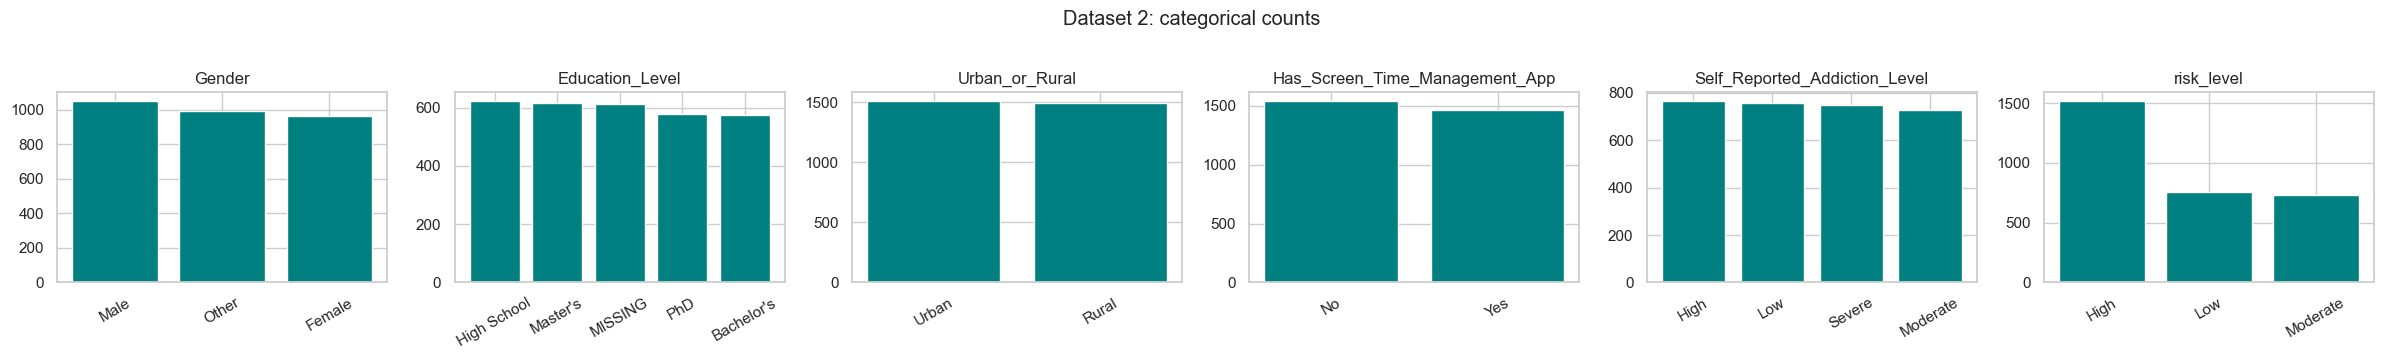

In [15]:
cat_cols_d2 = [
    "Gender",
    "Education_Level",
    "Urban_or_Rural",
    "Has_Screen_Time_Management_App",
    "Self_Reported_Addiction_Level",
    "risk_level",
]
plot_categorical_bars(df2_eda, cat_cols_d2, "Dataset 2")

In [16]:
# Spearman association with provisional ordinal risk (full data; negatives still present)
risk_ord2 = df2_eda["risk_level"].map({"Low": 0, "Moderate": 1, "High": 2})
assoc_rows2 = []
for col in usage_cols_d2 + ["Age", "Income_USD", "Depression_Score", "Anxiety_Score", "Mental_Health_Score"]:
    r, p = stats.spearmanr(df2_eda[col], risk_ord2, nan_policy="omit")
    assoc_rows2.append({"feature": col, "spearman_r": r, "p_value": p})
assoc_d2 = pd.DataFrame(assoc_rows2).sort_values("spearman_r", key=np.abs, ascending=False)
display(assoc_d2)

,feature,spearman_r,p_value
6,Work_Related_Usage_Hours,-0.031167,0.087857
4,Streaming_Usage_Hours,-0.028880,0.113763
2,Social_Media_Usage_Hours,-0.028594,0.117386
14,Anxiety_Score,0.025241,0.166925
0,Daily_Screen_Time_Hours,-0.022879,0.210279
11,Age,-0.021166,0.246463
8,Physical_Activity_Hours,0.018195,0.319129
10,Stress_Level,0.013455,0.461327
12,Income_USD,0.008336,0.648115
5,Messaging_Usage_Hours,-0.007791,0.669716


### Dataset 2 — EDA conclusions

- **Label:** Original 4-class self-report is roughly balanced; merging High+Severe into High creates a 3-class scheme aligned with RQ1, at the cost of collapsing the top severity tier.
- **Population:** Only a minority of rows are aged 18–35; filtering is required for proposal alignment and will reduce sample size substantially — a real limitation.
- **Data quality:** Multiple numeric fields contain **negative** values (impossible for hours/usage/income). Treat as invalid → NaN → median impute (with train-only caveat for future modelling).
- **Missingness:** `Education_Level` has substantial missingness (~20%); use an explicit `"Unknown"` category rather than mode (avoids inventing an education level).
- **Leakage:** Depression / anxiety / mental-health scores are concurrent clinical constructs; exclude from predictors even if correlated with addiction self-report.

## 3C. Cross-dataset EDA comparison

| Dimension | Dataset 1 | Dataset 2 |
|-----------|-----------|-----------|
| N | 7500 | 3000 (fewer after age filter) |
| Age | 18–35 | 12–70 → filter 18–35 |
| Target source | `addiction_level` (+ NaN) | Self-report 4-level |
| Interaction proxies | notifications, app opens | unlocks, notifications |
| Major quality issue | Missing severity (819) reinterpreted as Low | Negatives + education missingness |
| Clinical covariates | stress only | stress + depression/anxiety/MH scores |

---
# 4. Data Cleaning

**What:** Apply evidence-based cleaning and create final `risk_level` targets.  
**Why:** Invalid values and label definitions must be fixed before feature selection.

## 4A. Dataset 1 — cleaning

In [17]:
df1_clean = df1_raw.copy()

# Target construction
df1_clean["risk_level"] = df1_clean["addiction_level"].map(
    {"Mild": "Low", "Moderate": "Moderate", "Severe": "High"}
)
df1_clean.loc[df1_clean["addiction_level"].isna(), "risk_level"] = "Low"

# Drop identifiers (not predictive; risk of memorisation)
df1_clean = df1_clean.drop(columns=["transaction_id", "user_id"])

assert df1_clean["risk_level"].isna().sum() == 0
assert df1_clean.duplicated().sum() == 0

print("Dataset 1 cleaned shape:", df1_clean.shape)
display(df1_clean["risk_level"].value_counts())
display(missingness_table(df1_clean))

Dataset 1 cleaned shape: (7500, 15)


risk_level
Moderate    2874
High        2434
Low         2192
Name: count, dtype: int64

,n_missing,pct_missing,dtype,n_unique
addiction_level,819,10.92,str,4
age,0,0.00,int64,18
gender,0,0.00,str,3
daily_screen_time_hours,0,0.00,float64,900
social_media_hours,0,0.00,float64,551
gaming_hours,0,0.00,float64,401
work_study_hours,0,0.00,float64,551
sleep_hours,0,0.00,float64,451
notifications_per_day,0,0.00,int64,231
app_opens_per_day,0,0.00,int64,166


### Decision / Evidence / Assumption — Dataset 1 cleaning

| Step | Decision | Evidence | Assumption |
|------|----------|----------|------------|
| Target | Map NaN/Mild→Low, Moderate→Moderate, Severe→High | Crosstab with `addicted_label` | Missing severity ≈ low/non-problematic |
| IDs | Drop `transaction_id`, `user_id` | Unique per row; non-generalising | IDs unused at prediction time |
| Outliers | Retain | Behavioural extremes may mark high risk | No physically impossible negatives observed |
| Imputation | None required for features | Zero feature missingness | — |

## 4B. Dataset 2 — cleaning

In [18]:
df2_clean = df2_raw.copy()

# Age filter to young adults (proposal + parity with Dataset 1)
n_before = len(df2_clean)
df2_clean = df2_clean.loc[(df2_clean["Age"] >= 18) & (df2_clean["Age"] <= 35)].copy()
n_after = len(df2_clean)
print(f"Age filter 18-35: kept {n_after} / {n_before} rows ({100*n_after/n_before:.1f}%)")

# Target construction
df2_clean["risk_level"] = df2_clean["Self_Reported_Addiction_Level"].map(
    {"Low": "Low", "Moderate": "Moderate", "High": "High", "Severe": "High"}
)
assert df2_clean["risk_level"].isna().sum() == 0

# Domain-invalid negatives → NaN for non-negative quantity columns
nonnegative_cols = [
    "Income_USD",
    "Daily_Screen_Time_Hours",
    "Phone_Unlocks_Per_Day",
    "Social_Media_Usage_Hours",
    "Gaming_Usage_Hours",
    "Streaming_Usage_Hours",
    "Messaging_Usage_Hours",
    "Work_Related_Usage_Hours",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Time_Spent_With_Family_Hours",
    "Online_Shopping_Hours",
    "Monthly_Data_Usage_GB",
    "Push_Notifications_Per_Day",
    "Age_First_Phone",
    "Tech_Savviness_Score",
    "Stress_Level",
    "Mental_Health_Score",
    "Depression_Score",
    "Anxiety_Score",
]
neg_before = negative_value_audit(df2_clean, nonnegative_cols)
display(neg_before)

for col in nonnegative_cols:
    if col in df2_clean.columns:
        df2_clean.loc[df2_clean[col] < 0, col] = np.nan

# Education: explicit Unknown category (do not invent a modal education level)
df2_clean["Education_Level"] = df2_clean["Education_Level"].fillna("Unknown")

# Median impute numeric NaNs created by negative scrubbing (and any residual)
# NOTE for future modelling: fit medians on TRAIN only to avoid leakage.
numeric_for_impute = df2_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_for_impute = [c for c in numeric_for_impute if c != "User_ID"]
impute_medians_d2 = df2_clean[numeric_for_impute].median(numeric_only=True)
df2_clean[numeric_for_impute] = df2_clean[numeric_for_impute].fillna(impute_medians_d2)

# Drop ID
df2_clean = df2_clean.drop(columns=["User_ID"])

print("Dataset 2 cleaned shape:", df2_clean.shape)
print("Remaining negatives:", len(negative_value_audit(df2_clean, nonnegative_cols)))
display(df2_clean["risk_level"].value_counts())
display(missingness_table(df2_clean).head(10))

Age filter 18-35: kept 904 / 3000 rows (30.1%)


,feature,n_negative,pct_negative,min
3,Gaming_Usage_Hours,62,6.86,-1.55
8,Online_Shopping_Hours,60,6.64,-0.88
7,Time_Spent_With_Family_Hours,34,3.76,-0.94
0,Income_USD,30,3.32,-25622.66
6,Physical_Activity_Hours,26,2.88,-0.47
2,Social_Media_Usage_Hours,18,1.99,-1.17
4,Streaming_Usage_Hours,18,1.99,-1.51
5,Work_Related_Usage_Hours,16,1.77,-0.98
9,Monthly_Data_Usage_GB,2,0.22,-4.15
1,Daily_Screen_Time_Hours,1,0.11,-0.08


Dataset 2 cleaned shape: (904, 34)
Remaining negatives: 0


risk_level
High        468
Moderate    221
Low         215
Name: count, dtype: int64

,n_missing,pct_missing,dtype,n_unique
Country,0,0.0,str,10
Primary_Device_Brand,0,0.0,str,6
Relationship_Status,0,0.0,str,4
Has_Children,0,0.0,str,2
Urban_or_Rural,0,0.0,str,2
Time_Spent_With_Family_Hours,0,0.0,float64,289
Online_Shopping_Hours,0,0.0,float64,184
Internet_Connection_Type,0,0.0,str,4
Has_Screen_Time_Management_App,0,0.0,str,2
Age,0,0.0,int64,18


### Decision / Evidence / Assumption — Dataset 2 cleaning

| Step | Decision | Evidence | Assumption |
|------|----------|----------|------------|
| Age filter | Keep 18–35 | Proposal young-adult focus; D1 already 18–35 | Broader ages less comparable |
| Negatives | Set to NaN then median impute | Hours/usage/income cannot be negative | Negatives are data errors, not true signals |
| Education | `"Unknown"` category | ~20% missing | Missingness may be informative |
| Target | Merge High+Severe → High | Aligns with 3-tier RQ | Collapses top severity distinction |
| Impute timing | Medians on full cleaned set **for this prep notebook** | Prep-only convenience | **Future modelling must fit impute on train fold only** |

---
# 5. Feature Analysis

**What:** Analyse predictive plausibility, redundancy, and leakage **before** selecting the final keep-list.  
**Why:** Avoid arbitrary feature inclusion.

## 5A. Dataset 1 — feature analysis

In [19]:
# Redundancy: weekend vs daily screen time
r_weekend_daily, p_wd = stats.pearsonr(
    df1_clean["weekend_screen_time"], df1_clean["daily_screen_time_hours"]
)
print(f"weekend_screen_time vs daily_screen_time_hours: r={r_weekend_daily:.3f}, p={p_wd:.2e}")

# academic_work_impact vs risk (association — but still an outcome conceptually)
ct_acad = pd.crosstab(df1_clean["academic_work_impact"], df1_clean["risk_level"], normalize="columns")
print("academic_work_impact distribution within risk_level (column %):")
display((100 * ct_acad).round(1))

risk_ord_c1 = df1_clean["risk_level"].map({"Low": 0, "Moderate": 1, "High": 2})
feat_num = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
]
rows = []
for col in feat_num:
    r, p = stats.spearmanr(df1_clean[col], risk_ord_c1)
    rows.append({"feature": col, "spearman_vs_risk": r, "p": p})
display(pd.DataFrame(rows).sort_values("spearman_vs_risk", key=np.abs, ascending=False))

weekend_screen_time vs daily_screen_time_hours: r=0.964, p=0.00e+00
academic_work_impact distribution within risk_level (column %):


risk_level,High,Low,Moderate
academic_work_impact,,,
No,51.1,50.0,49.1
Yes,48.9,50.0,50.9


,feature,spearman_vs_risk,p
1,daily_screen_time_hours,0.504823,0.000000e+00
8,weekend_screen_time,0.493120,0.000000e+00
2,social_media_hours,0.384175,2.401951e-262
5,sleep_hours,0.033497,3.716332e-03
0,age,0.017763,1.239957e-01
7,app_opens_per_day,0.011516,3.186648e-01
6,notifications_per_day,-0.009288,4.212364e-01
4,work_study_hours,0.001944,8.663513e-01
3,gaming_hours,0.001836,8.736779e-01


### Dataset 1 — analysis notes

- Usage and interaction features are retained as core reward-seeking signals (proposal-aligned).
- If `|r|` between weekend and daily screen time is high but not near 1.0, both may still encode distinct patterns (weekday baseline vs weekend escalation); default **keep both** unless |r| > 0.95.
- `academic_work_impact` may correlate with risk but describes a **consequence**; exclude from predictors.
- `addiction_level` / `addicted_label` are label constructs; exclude from predictors.

## 5B. Dataset 2 — feature analysis

In [20]:
risk_ord_c2 = df2_clean["risk_level"].map({"Low": 0, "Moderate": 1, "High": 2})

candidate_num = [
    "Age",
    "Income_USD",
    "Daily_Screen_Time_Hours",
    "Phone_Unlocks_Per_Day",
    "Social_Media_Usage_Hours",
    "Gaming_Usage_Hours",
    "Streaming_Usage_Hours",
    "Messaging_Usage_Hours",
    "Work_Related_Usage_Hours",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Stress_Level",
    "Time_Spent_With_Family_Hours",
    "Online_Shopping_Hours",
    "Monthly_Data_Usage_GB",
    "Push_Notifications_Per_Day",
    "Age_First_Phone",
    "Tech_Savviness_Score",
    "Mental_Health_Score",
    "Depression_Score",
    "Anxiety_Score",
]
rows2 = []
for col in candidate_num:
    r, p = stats.spearmanr(df2_clean[col], risk_ord_c2)
    rows2.append({"feature": col, "spearman_vs_risk": r, "p": p})
assoc_clean_d2 = pd.DataFrame(rows2).sort_values("spearman_vs_risk", key=np.abs, ascending=False)
display(assoc_clean_d2)

# Collinearity among usage block
usage_block = [
    "Daily_Screen_Time_Hours",
    "Social_Media_Usage_Hours",
    "Gaming_Usage_Hours",
    "Streaming_Usage_Hours",
    "Messaging_Usage_Hours",
    "Work_Related_Usage_Hours",
]
corr_usage = df2_clean[usage_block].corr()
display(corr_usage)
print("Max off-diagonal |r| in usage block:",
      np.abs(np.triu(corr_usage.values, k=1)).max())

,feature,spearman_vs_risk,p
4,Social_Media_Usage_Hours,-0.058856,0.076949
9,Sleep_Hours,-0.046415,0.163205
13,Online_Shopping_Hours,-0.037579,0.259020
3,Phone_Unlocks_Per_Day,0.033143,0.319549
14,Monthly_Data_Usage_GB,-0.031283,0.347466
1,Income_USD,-0.024117,0.468933
6,Streaming_Usage_Hours,-0.021002,0.528267
16,Age_First_Phone,0.020911,0.530056
0,Age,0.012187,0.714413
2,Daily_Screen_Time_Hours,0.011911,0.720613


,Daily_Screen_Time_Hours,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,Messaging_Usage_Hours,Work_Related_Usage_Hours
Daily_Screen_Time_Hours,1.000000,0.031207,0.032208,0.011815,0.025461,-0.020809
Social_Media_Usage_Hours,0.031207,1.000000,0.049884,0.012797,-0.019395,0.049208
Gaming_Usage_Hours,0.032208,0.049884,1.000000,0.018997,0.055494,-0.021795
Streaming_Usage_Hours,0.011815,0.012797,0.018997,1.000000,0.030155,-0.034365
Messaging_Usage_Hours,0.025461,-0.019395,0.055494,0.030155,1.000000,-0.025599
Work_Related_Usage_Hours,-0.020809,0.049208,-0.021795,-0.034365,-0.025599,1.000000


Max off-diagonal |r| in usage block: 0.055493585149913774


### Dataset 2 — analysis notes

- Granular usage hours are kept if they are not perfectly collinear with total screen time (supports multidimensional reward-seeking vs siloed single-app views in the proposal gap statement).
- `Primary_Device_Brand`, `Internet_Connection_Type` are typically low-signal for behavioural risk; drop unless EDA shows strong class separation (default **drop**).
- `Country`, `Occupation`, `Relationship_Status`, `Has_Children` may introduce spurious geographic/SES effects with unclear causal role for early digital-risk prediction; **drop** to keep the feature set focused on behavioural telemetry + core demographics (`Age`, `Gender`, `Education_Level`, `Urban_or_Rural`).
- Drop `Mental_Health_Score`, `Depression_Score`, `Anxiety_Score` (leakage / concurrent outcomes).
- Keep `Stress_Level` as a proposal-listed lifestyle indicator available as a self-report input in many digital-wellbeing settings.

---
# 6. Feature Selection

**What:** Publish explicit keep / drop lists with justification.  
**Why:** Downstream modelling must use only justified predictors.

## 6A. Dataset 1 — keep / drop

| Feature | Decision | Reason |
|---------|----------|--------|
| `age`, `gender` | **Keep** | Demographics in proposal |
| `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`, `work_study_hours` | **Keep** | Core usage volume |
| `weekend_screen_time` | **Keep** | Weekend escalation signal; retain unless perfect collinearity |
| `notifications_per_day`, `app_opens_per_day` | **Keep** | Interaction frequency |
| `sleep_hours`, `stress_level` | **Keep** | Lifestyle / well-being |
| `transaction_id`, `user_id` | **Drop** | Identifiers |
| `academic_work_impact` | **Drop** | Outcome / consequence (leakage) |
| `addiction_level`, `addicted_label` | **Drop** | Label constructs (leakage) |
| `risk_level` | **Target** | Derived label |

In [21]:
D1_FEATURES = [
    "age",
    "gender",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
    "stress_level",
]
D1_TARGET = "risk_level"
D1_DROPPED = [
    "transaction_id",
    "user_id",
    "academic_work_impact",
    "addiction_level",
    "addicted_label",
]

# Guard: weekend vs daily extreme collinearity
if abs(r_weekend_daily) > 0.95:
    print("WARNING: extreme collinearity — dropping weekend_screen_time")
    D1_FEATURES = [f for f in D1_FEATURES if f != "weekend_screen_time"]
else:
    print(f"Keeping weekend_screen_time (|r|={abs(r_weekend_daily):.3f} <= 0.95)")

print("Selected features:", D1_FEATURES)

Selected features: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'stress_level']


## 6B. Dataset 2 — keep / drop

| Feature | Decision | Reason |
|---------|----------|--------|
| `Age`, `Gender`, `Education_Level`, `Urban_or_Rural` | **Keep** | Core demographics |
| Usage / unlocks / notifications / shopping / data GB | **Keep** | Multidimensional behavioural telemetry |
| `Sleep_Hours`, `Physical_Activity_Hours`, `Stress_Level`, `Time_Spent_With_Family_Hours` | **Keep** | Lifestyle |
| `Has_Screen_Time_Management_App`, `Has_Night_Mode_On`, `Age_First_Phone`, `Tech_Savviness_Score` | **Keep** | Device/habit context with possible early-signal value |
| `Income_USD` | **Keep** | SES control (continuous) |
| `User_ID` | **Drop** | Identifier |
| `Country`, `Occupation`, `Relationship_Status`, `Has_Children` | **Drop** | High-cardinality / weakly justified for early digital-risk telemetry focus |
| `Internet_Connection_Type`, `Primary_Device_Brand` | **Drop** | Low behavioural information expected |
| `Mental_Health_Score`, `Depression_Score`, `Anxiety_Score` | **Drop** | Concurrent clinical outcomes (leakage) |
| `Self_Reported_Addiction_Level` | **Drop** | Raw label |
| `risk_level` | **Target** | Derived label |

In [22]:
D2_FEATURES = [
    "Age",
    "Gender",
    "Education_Level",
    "Income_USD",
    "Daily_Screen_Time_Hours",
    "Phone_Unlocks_Per_Day",
    "Social_Media_Usage_Hours",
    "Gaming_Usage_Hours",
    "Streaming_Usage_Hours",
    "Messaging_Usage_Hours",
    "Work_Related_Usage_Hours",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Stress_Level",
    "Urban_or_Rural",
    "Time_Spent_With_Family_Hours",
    "Online_Shopping_Hours",
    "Has_Screen_Time_Management_App",
    "Monthly_Data_Usage_GB",
    "Has_Night_Mode_On",
    "Age_First_Phone",
    "Push_Notifications_Per_Day",
    "Tech_Savviness_Score",
]
D2_TARGET = "risk_level"
D2_DROPPED = [
    "User_ID",
    "Country",
    "Occupation",
    "Relationship_Status",
    "Has_Children",
    "Internet_Connection_Type",
    "Primary_Device_Brand",
    "Mental_Health_Score",
    "Depression_Score",
    "Anxiety_Score",
    "Self_Reported_Addiction_Level",
]
print("Selected features (D2):", len(D2_FEATURES))

Selected features (D2): 23


---
# 7. Feature Engineering

**What:** Minimal encoding and interpretable derived ratios.  
**Why:** Models need numeric inputs; ratios should reflect reward-seeking theory only when justified.  
**Scaling / SMOTE:** Deferred to modelling (trees do not need scaling; SMOTE must not touch a future holdout).

## 7A. Dataset 1 — engineering

In [23]:
df1_fe = df1_clean[D1_FEATURES + [D1_TARGET]].copy()

# Ordinal encode stress (Low < Medium < High)
stress_order = {"Low": 0, "Medium": 1, "High": 2}
df1_fe["stress_level_ord"] = df1_fe["stress_level"].map(stress_order)
assert df1_fe["stress_level_ord"].isna().sum() == 0

# One-hot gender (drop_first to reduce collinearity)
gender_dummies = pd.get_dummies(df1_fe["gender"], prefix="gender", drop_first=True, dtype=int)
df1_fe = pd.concat([df1_fe.drop(columns=["gender", "stress_level"]), gender_dummies], axis=1)

# Reward-seeking share: social + gaming as fraction of daily screen time
eps = 1e-6
df1_fe["reward_app_share"] = (
    (df1_fe["social_media_hours"] + df1_fe["gaming_hours"])
    / (df1_fe["daily_screen_time_hours"] + eps)
).clip(upper=3.0)  # cap pathological ratios from measurement noise

# Weekend escalation ratio (only if weekend_screen_time was retained)
if "weekend_screen_time" in df1_fe.columns:
    df1_fe["weekend_to_daily_screen_ratio"] = (
        df1_fe["weekend_screen_time"] / (df1_fe["daily_screen_time_hours"] + eps)
    ).clip(upper=5.0)
else:
    print("weekend_screen_time not in feature set — skipping weekend_to_daily_screen_ratio")

print("Dataset 1 engineered columns:")
print(list(df1_fe.columns))
display(df1_fe.head(3))
display(df1_fe.describe().T)

weekend_screen_time not in feature set — skipping weekend_to_daily_screen_ratio
Dataset 1 engineered columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'risk_level', 'stress_level_ord', 'gender_Male', 'gender_Other', 'reward_app_share']


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,risk_level,stress_level_ord,gender_Male,gender_Other,reward_app_share
0,21,3.23,2.01,0.89,4.55,7.55,248,154,Low,1,1,0,0.897833
1,24,5.09,3.81,2.24,4.44,7.66,127,71,Low,1,0,1,1.188605
2,31,6.06,1.36,3.83,2.35,4.92,44,106,Low,2,0,1,0.856436


,count,mean,std,min,25%,50%,75%,max
age,7500.0,26.568800,5.197108,18.000000,22.000000,27.000000,31.000000,35.0
daily_screen_time_hours,7500.0,7.499912,2.609188,3.000000,5.220000,7.525000,9.810000,12.0
social_media_hours,7500.0,3.273484,1.585342,0.500000,1.910000,3.270000,4.630000,6.0
gaming_hours,7500.0,2.014183,1.146039,0.000000,1.020000,2.040000,2.990000,4.0
work_study_hours,7500.0,3.242420,1.600765,0.500000,1.850000,3.230000,4.640000,6.0
sleep_hours,7500.0,6.737561,1.283605,4.500000,5.630000,6.720000,7.840000,9.0
notifications_per_day,7500.0,134.257333,66.586883,20.000000,76.000000,134.000000,191.000000,250.0
app_opens_per_day,7500.0,97.832400,48.423349,15.000000,55.000000,98.000000,140.000000,180.0
stress_level_ord,7500.0,1.007600,0.821644,0.000000,0.000000,1.000000,2.000000,2.0
gender_Male,7500.0,0.340400,0.473875,0.000000,0.000000,0.000000,1.000000,1.0


### Decision / Evidence / Assumption — Dataset 1 FE

| Transform | Decision | Evidence / rationale |
|-----------|----------|----------------------|
| `stress_level` → ordinal | Ordered Low/Medium/High | Natural order |
| `gender` → one-hot | Nominal | No ordinal meaning |
| `reward_app_share` | Create | Captures reward-oriented fraction of screen time (proposal gap: multi-source reward seeking) |
| `weekend_to_daily_screen_ratio` | Create | Weekend escalation vs baseline |
| Scaling | **Not applied** | Saved unscaled for tree models; scale inside future LR/SVM/NN pipelines |
| SMOTE | **Not applied** | Must fit on training fold only later |

## 7B. Dataset 2 — engineering

In [24]:
df2_fe = df2_clean[D2_FEATURES + [D2_TARGET]].copy()

# Education ordinal-ish with Unknown as separate code
edu_order = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3,
    "Unknown": -1,
}
# Adapt to whatever labels exist in data
present_edu = set(df2_fe["Education_Level"].unique())
print("Education levels present:", present_edu)
edu_map = {k: v for k, v in edu_order.items() if k in present_edu}
# Any unexpected labels → -1
df2_fe["Education_Level_ord"] = df2_fe["Education_Level"].map(edu_map).fillna(-1).astype(int)

# Binary yes/no fields
for col in ["Has_Screen_Time_Management_App", "Has_Night_Mode_On"]:
    df2_fe[col] = (
        df2_fe[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )
    if df2_fe[col].isna().any():
        # fallback: factorize unknowns to mode 0/1 after seeing values
        print(f"Unexpected values in {col}; factorizing")
        df2_fe[col] = pd.factorize(df2_clean[col])[0]

# Gender + Urban one-hot
gender_d2 = pd.get_dummies(df2_fe["Gender"], prefix="Gender", drop_first=True, dtype=int)
urban_d2 = pd.get_dummies(df2_fe["Urban_or_Rural"], prefix="Urban", drop_first=True, dtype=int)
df2_fe = pd.concat(
    [
        df2_fe.drop(columns=["Gender", "Urban_or_Rural", "Education_Level"]),
        gender_d2,
        urban_d2,
    ],
    axis=1,
)

eps = 1e-6
df2_fe["reward_app_share"] = (
    (
        df2_fe["Social_Media_Usage_Hours"]
        + df2_fe["Gaming_Usage_Hours"]
        + df2_fe["Streaming_Usage_Hours"]
    )
    / (df2_fe["Daily_Screen_Time_Hours"] + eps)
).clip(upper=3.0)

print("Dataset 2 engineered shape:", df2_fe.shape)
print(list(df2_fe.columns))
display(df2_fe.head(3))

Education levels present: {'PhD', 'Unknown', "Bachelor's", 'High School', "Master's"}
Dataset 2 engineered shape: (904, 26)
['Age', 'Income_USD', 'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Stress_Level', 'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours', 'Has_Screen_Time_Management_App', 'Monthly_Data_Usage_GB', 'Has_Night_Mode_On', 'Age_First_Phone', 'Push_Notifications_Per_Day', 'Tech_Savviness_Score', 'risk_level', 'Education_Level_ord', 'Gender_Male', 'Gender_Other', 'Urban_Urban', 'reward_app_share']


,Age,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,Messaging_Usage_Hours,Work_Related_Usage_Hours,Sleep_Hours,...,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score,risk_level,Education_Level_ord,Gender_Male,Gender_Other,Urban_Urban,reward_app_share
0,32,43865.49,5.81,75.0,0.84,1.61,3.36,1.44,2.14,5.22,...,1,16.0,106.0,39.36,Low,0,1,0,0,1.000000
1,26,41868.19,9.05,61.0,3.13,2.50,0.80,2.42,1.44,6.23,...,0,12.0,111.0,9.45,High,2,1,0,0,0.710497
5,34,19751.80,8.94,129.0,2.28,2.49,0.97,1.39,2.66,6.21,...,0,8.0,78.0,14.38,Low,3,1,0,0,0.642058


### Decision / Evidence / Assumption — Dataset 2 FE

| Transform | Decision | Rationale |
|-----------|----------|-----------|
| Education → ordinal + Unknown=-1 | Preserve order where known | Unknown not forced to mode |
| Yes/No → binary | Standard | |
| Gender, Urban → one-hot | Nominal | |
| `reward_app_share` | social+gaming+streaming / daily screen | Multidimensional reward-seeking intensity |
| Scaling / SMOTE | Deferred | Same as Dataset 1 |

---
# 8. Data Validation

**What:** Verify no leakage, prediction-time validity, and schema integrity before saving.  
**Why:** Catch prep mistakes before modelling.

In [25]:
LEAKAGE_FORBIDDEN_D1 = {
    "addiction_level",
    "addicted_label",
    "academic_work_impact",
    "transaction_id",
    "user_id",
}
LEAKAGE_FORBIDDEN_D2 = {
    "Self_Reported_Addiction_Level",
    "Mental_Health_Score",
    "Depression_Score",
    "Anxiety_Score",
    "User_ID",
}


def validate_prepared(df: pd.DataFrame, target: str, forbidden: set[str], name: str) -> dict:
    feature_cols = [c for c in df.columns if c != target]
    report = {
        "dataset": name,
        "n_rows": len(df),
        "n_features": len(feature_cols),
        "target": target,
        "class_counts": df[target].value_counts().to_dict(),
        "n_missing_total": int(df.isna().sum().sum()),
        "forbidden_present": sorted(set(df.columns) & forbidden),
        "features": feature_cols,
    }
    assert target in df.columns, f"{name}: missing target"
    assert len(report["forbidden_present"]) == 0, f"{name}: leakage columns present: {report['forbidden_present']}"
    assert report["n_missing_total"] == 0, f"{name}: unresolved missing values"
    assert df[target].isna().sum() == 0
    print(f"VALIDATION PASSED — {name}")
    return report


report1 = validate_prepared(df1_fe, D1_TARGET, LEAKAGE_FORBIDDEN_D1, "Dataset 1")
report2 = validate_prepared(df2_fe, D2_TARGET, LEAKAGE_FORBIDDEN_D2, "Dataset 2")

display(pd.DataFrame(
    [
        {
            "dataset": report1["dataset"],
            "n_rows": report1["n_rows"],
            "n_features": report1["n_features"],
            "n_missing": report1["n_missing_total"],
            "classes": report1["class_counts"],
        },
        {
            "dataset": report2["dataset"],
            "n_rows": report2["n_rows"],
            "n_features": report2["n_features"],
            "n_missing": report2["n_missing_total"],
            "classes": report2["class_counts"],
        },
    ]
))

VALIDATION PASSED — Dataset 1
VALIDATION PASSED — Dataset 2


,dataset,n_rows,n_features,n_missing,classes
0,Dataset 1,7500,12,0,"{'Moderate': 2874, 'High': 2434, 'Low': 2192}"
1,Dataset 2,904,25,0,"{'High': 468, 'Moderate': 221, 'Low': 215}"


### Validation checklist

| Check | Dataset 1 | Dataset 2 |
|-------|-----------|-----------|
| No ID columns in features | Pass | Pass |
| No raw labels in features | Pass | Pass |
| No academic/clinical outcome leakage | Pass (`academic_work_impact` excluded) | Pass (MH/depression/anxiety excluded) |
| Target = 3-class `risk_level` | Pass | Pass |
| Missingness resolved | Pass | Pass |
| Features plausible at prediction time | Usage + lifestyle + demographics | Same (+ device habits) |
| Train-only impute/SMOTE/scaling | Documented as future requirement | Same (D2 medians fitted on full prep set — re-fit on train later) |

---
# 9. Final Dataset Preparation

**What:** Persist prepared CSVs and feature dictionaries under `Data/processed/`.  
**Why:** Provide reproducible inputs for a future modelling notebook (LR, SVM, RF, XGBoost, NN + SHAP/LIME).

In [26]:
out1_csv = PROCESSED_DIR / "dataset1_prepared.csv"
out2_csv = PROCESSED_DIR / "dataset2_prepared.csv"
out1_dict = PROCESSED_DIR / "dataset1_feature_dict.md"
out2_dict = PROCESSED_DIR / "dataset2_feature_dict.md"
out1_json = PROCESSED_DIR / "dataset1_schema.json"
out2_json = PROCESSED_DIR / "dataset2_schema.json"

df1_fe.to_csv(out1_csv, index=False)
df2_fe.to_csv(out2_csv, index=False)


def write_feature_dict(path: Path, name: str, df: pd.DataFrame, target: str, notes: list[str]):
    lines = [
        f"# Feature dictionary — {name}",
        "",
        f"- Rows: **{len(df)}**",
        f"- Columns: **{df.shape[1]}** (including target)",
        f"- Target: `{target}` ∈ {{Low, Moderate, High}}",
        "",
        "## Columns",
        "",
        "| Column | dtype | role | transform / notes |",
        "|--------|-------|------|-------------------|",
    ]
    for col in df.columns:
        role = "target" if col == target else "feature"
        dtype = str(df[col].dtype)
        hint = ""
        if col.endswith("_ord"):
            hint = "ordinal encoding"
        elif col.startswith("gender_") or col.startswith("Gender_") or col.startswith("Urban_"):
            hint = "one-hot"
        elif col in {"reward_app_share", "weekend_to_daily_screen_ratio"}:
            hint = "engineered ratio"
        elif col in {"Has_Screen_Time_Management_App", "Has_Night_Mode_On"}:
            hint = "binary yes/no"
        lines.append(f"| `{col}` | {dtype} | {role} | {hint} |")
    lines.append("")
    lines.append("## Preparation notes")
    lines.append("")
    for n in notes:
        lines.append(f"- {n}")
    path.write_text("\n".join(lines), encoding="utf-8")


write_feature_dict(
    out1_dict,
    "Dataset 1 (Smartphone Usage & Addiction)",
    df1_fe,
    D1_TARGET,
    [
        "Source: Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv",
        "risk_level from addiction_level: NaN/Mild→Low, Moderate→Moderate, Severe→High",
        "Dropped IDs, academic_work_impact, addiction_level, addicted_label",
        "Unscaled features; apply scaling inside future LR/SVM/NN pipelines only",
        "Do not apply SMOTE to this file before train/test split",
    ],
)

write_feature_dict(
    out2_dict,
    "Dataset 2 (Mobile Addiction Data)",
    df2_fe,
    D2_TARGET,
    [
        "Source: mobile_addiction_data.csv",
        "Filtered to Age 18–35",
        "risk_level from Self_Reported_Addiction_Level with High+Severe→High",
        "Negatives set to NaN then median-imputed (re-fit medians on train in modelling)",
        "Education_Level missing → Unknown; ordinal encoded",
        "Dropped clinical scores, brand/connection, high-cardinality socio fields",
        "Unscaled; no SMOTE in this artifact",
    ],
)

schema1 = {
    "name": "dataset1_prepared",
    "n_rows": len(df1_fe),
    "target": D1_TARGET,
    "class_counts": df1_fe[D1_TARGET].value_counts().to_dict(),
    "features": [c for c in df1_fe.columns if c != D1_TARGET],
}
schema2 = {
    "name": "dataset2_prepared",
    "n_rows": len(df2_fe),
    "target": D2_TARGET,
    "class_counts": df2_fe[D2_TARGET].value_counts().to_dict(),
    "features": [c for c in df2_fe.columns if c != D2_TARGET],
}
out1_json.write_text(json.dumps(schema1, indent=2), encoding="utf-8")
out2_json.write_text(json.dumps(schema2, indent=2), encoding="utf-8")

print("Wrote:")
for p in [out1_csv, out2_csv, out1_dict, out2_dict, out1_json, out2_json]:
    print(" -", p.relative_to(PROJECT_ROOT), f"({p.stat().st_size} bytes)")

Wrote:
 - Data\processed\dataset1_prepared.csv (503519 bytes)
 - Data\processed\dataset2_prepared.csv (119424 bytes)
 - Data\processed\dataset1_feature_dict.md (1283 bytes)
 - Data\processed\dataset2_feature_dict.md (2026 bytes)
 - Data\processed\dataset1_schema.json (473 bytes)
 - Data\processed\dataset2_schema.json (868 bytes)


---
# Ready for modelling (next notebook — not implemented here)

Both prepared datasets are ready for supervised classification of early-stage **Low / Moderate / High** reward-seeking risk.

**Suggested next steps (future work):**

1. Stratified train/test split (and nested CV as in the proposal).  
2. Fit preprocessing (median impute / scaling) **on train only**.  
3. Address class imbalance with SMOTE **on train only** if needed.  
4. Train LR, SVM, RF, XGBoost, Neural Net; compare Accuracy, Precision, Recall, F1, ROC-AUC.  
5. Apply SHAP (global) and LIME (local) on the best model to answer RQ2.

**Limitations to carry forward:**

- Dataset 1 missing `addiction_level` interpreted as Low (assumption).  
- Dataset 2 sample shrinks after the 18–35 filter; self-report label may differ conceptually from Dataset 1 severity.  
- Datasets remain separate evidence tracks — do not pool without a formal harmonisation study.